In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MAX_LEN    = 64
VOCAB_SIZE = 10000
D_MODEL    = 128
NUM_HEADS  = 8
NUM_LAYERS = 3
D_FF       = 256
DROPOUT    = 0.1
BATCH_SIZE = 128
NUM_EPOCHS = 5
LR         = 1e-3

Using device: cpu


In [2]:
DATA_PATH = r"d:\dut_ai\AIO_code\Encoder transformer\data\sentiment_data.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))
print("\nLabel distribution:")
print(df['Sentiment'].value_counts())

Shape: (241145, 3)
Columns: ['Unnamed: 0', 'Comment', 'Sentiment']
   Unnamed: 0                                            Comment  Sentiment
0           0  lets forget apple pay required brand new iphon...          1
1           1  nz retailers don’t even contactless credit car...          0
2           2  forever acknowledge channel help lessons ideas...          2

Label distribution:
Sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64


In [3]:
def simple_tokenize(text):
    return str(text).lower().split()

def build_vocab(texts, max_vocab=10000):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))
    
    vocab = {"<PAD>": 0, "<UNK>": 1, "<CLS>": 2}
    for word, _ in counter.most_common(max_vocab - len(vocab)):
        vocab[word] = len(vocab)
    return vocab

def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(text)
    ids = [vocab["<CLS>"]]
    for token in tokens[:max_len - 1]:
        ids.append(vocab.get(token, vocab["<UNK>"]))
    ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    return ids[:max_len]

df = df.sample(50000, random_state=42).reset_index(drop=True)

vocab = build_vocab(df['Comment'].tolist(), max_vocab=VOCAB_SIZE)
VOCAB_SIZE = len(vocab)
num_classes = df['Sentiment'].nunique()

print(f"Vocab size: {VOCAB_SIZE}")
print(f"Num classes: {num_classes}")

Vocab size: 10000
Num classes: 3


In [4]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.encodings = [encode_text(t, vocab, max_len) for t in tqdm(texts, desc="Encoding")]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],    dtype=torch.long)
        )

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Comment'].tolist(),
    df['Sentiment'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']
)

train_dataset = SentimentDataset(train_texts, train_labels, vocab)
val_dataset   = SentimentDataset(val_texts,   val_labels,   vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Encoding: 100%|██████████| 10000/10000 [00:00<00:00, 143512.76it/s]

Train: 40000 | Val: 10000


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads
        self.q_linear   = nn.Linear(d_model, d_model)
        self.k_linear   = nn.Linear(d_model, d_model)
        self.v_linear   = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q_proj = self.q_linear(q).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        k_proj = self.k_linear(k).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        v_proj = self.v_linear(v).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(q_proj, k_proj.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_probs = self.dropout(F.softmax(scores, dim=-1))
        attn_out   = torch.matmul(attn_probs, v_proj)
        attn_concat = attn_out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.out_linear(attn_concat), attn_probs


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha      = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn      = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1    = nn.LayerNorm(d_model)
        self.norm2    = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, _ = self.mha(x, x, x, mask=mask)
        x = self.norm1(x + self.dropout1(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        out = self.token_embedding(x)
        out = self.positional_encoding(out)
        for layer in self.layers:
            out = layer(out, mask=mask)
        return self.norm(out)

In [6]:
class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads,
                 d_ff, num_classes, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size=vocab_size, d_model=d_model, num_layers=num_layers,
            num_heads=num_heads, d_ff=d_ff, max_len=max_len, dropout=dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, input_ids):
        # Tạo padding mask
        mask = (input_ids != 0).unsqueeze(1).unsqueeze(2)  # [B,1,1,seq_len]
        enc_output = self.encoder(input_ids, mask=mask)    # [B, seq_len, d_model]
        cls_vector = enc_output[:, 0, :]                   # [B, d_model]
        return self.classifier(cls_vector)                 # [B, num_classes]


model = SentimentClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_classes=num_classes,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng tham số: {total_params:,}")

Tổng tham số: 1,686,147


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc="Training")
    for ids, labels in pbar:
        ids, labels = ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(ids)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        correct += (logits.argmax(-1) == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for ids, labels in loader:
            ids, labels = ids.to(device), labels.to(device)
            logits = model(ids)
            loss = criterion(logits, labels)
            correct    += (logits.argmax(-1) == labels).sum().item()
            total      += labels.size(0)
            total_loss += loss.item()
    return total_loss / len(loader), correct / total

# --- Train ---
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = eval_epoch(model,  val_loader,   criterion)
    scheduler.step()
    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);   val_accs.append(v_acc)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

Training: 100%|██████████| 313/313 [04:05<00:00,  1.28it/s, acc=0.5769, loss=0.7718]



Epoch 1/5 | Train Loss: 0.9045 Acc: 0.5769 | Val Loss: 0.7554 Acc: 0.6718


Training: 100%|██████████| 313/313 [04:27<00:00,  1.17it/s, acc=0.6998, loss=0.5830]



Epoch 2/5 | Train Loss: 0.7148 Acc: 0.6998 | Val Loss: 0.6914 Acc: 0.7256


Training: 100%|██████████| 313/313 [03:43<00:00,  1.40it/s, acc=0.7555, loss=0.5635]



Epoch 3/5 | Train Loss: 0.6064 Acc: 0.7555 | Val Loss: 0.6217 Acc: 0.7625


Training: 100%|██████████| 313/313 [03:35<00:00,  1.45it/s, acc=0.7752, loss=0.4906]



Epoch 4/5 | Train Loss: 0.5644 Acc: 0.7752 | Val Loss: 0.5926 Acc: 0.7710


Training: 100%|██████████| 313/313 [03:34<00:00,  1.46it/s, acc=0.7968, loss=0.6166]



Epoch 5/5 | Train Loss: 0.5206 Acc: 0.7968 | Val Loss: 0.5915 Acc: 0.7802


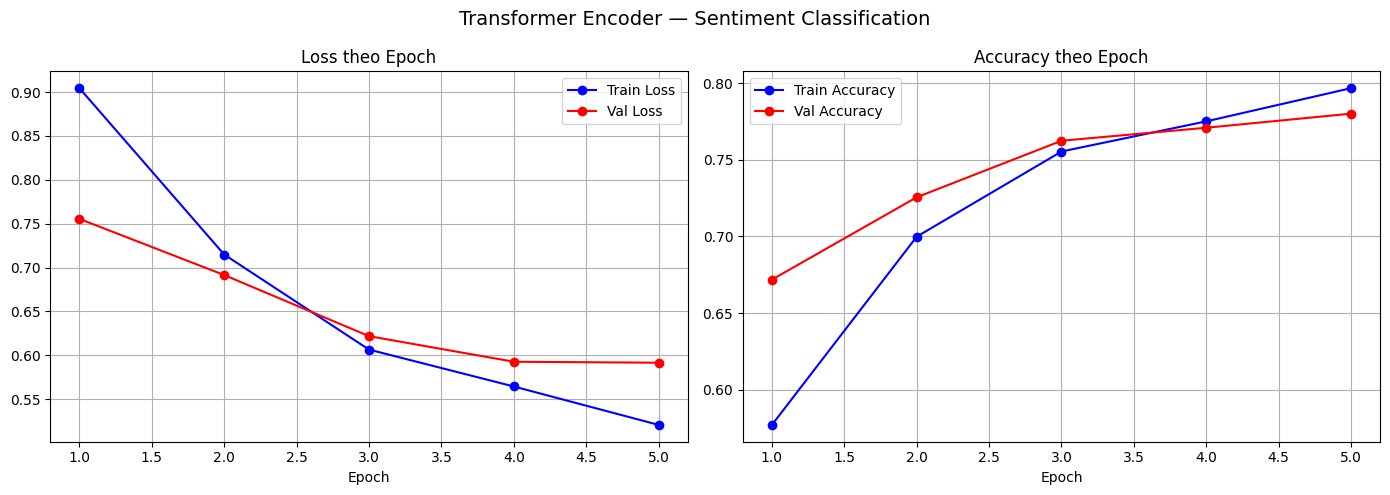

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, train_losses, 'b-o', label='Train Loss')
axes[0].plot(ep, val_losses,   'r-o', label='Val Loss')
axes[0].set_title('Loss theo Epoch'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, train_accs, 'b-o', label='Train Accuracy')
axes[1].plot(ep, val_accs,   'r-o', label='Val Accuracy')
axes[1].set_title('Accuracy theo Epoch'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Transformer Encoder — Sentiment Classification', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
label_names = {0: "Negative", 1: "Positive", 2: "Neutral"}

def predict(text, model, vocab):
    model.eval()
    ids = torch.tensor([encode_text(text, vocab)], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(ids)
        probs  = F.softmax(logits, dim=-1)[0]
        pred   = logits.argmax(-1).item()
    return label_names[pred], probs.tolist()

tests = [
    "This product is absolutely amazing, I love it!",
    "Terrible quality, complete waste of money.",
    "It works fine, nothing special.",
]
for sent in tests:
    label, probs = predict(sent, model, vocab)
    print(f"Text   : {sent}")
    print(f"Label  : {label} | Probs: {[f'{p:.2%}' for p in probs]}\n")

Text   : This product is absolutely amazing, I love it!
Label  : Neutral | Probs: ['0.95%', '6.01%', '93.04%']

Text   : Terrible quality, complete waste of money.
Label  : Negative | Probs: ['87.80%', '10.50%', '1.70%']

Text   : It works fine, nothing special.
Label  : Positive | Probs: ['13.60%', '67.74%', '18.66%']

